In [1]:
from dotenv import load_dotenv
from langchain_classic.chains.question_answering.map_reduce_prompt import messages

load_dotenv()


True

In [2]:
from langchain_ollama import ChatOllama

# Initialize the local model running on your M4
# Use a fast model like 'phi3:mini' or 'llama3.1:8b'
llm = ChatOllama(
    model="llama3.2:latest",
    temperature=0,
    base_url="http://localhost:11434" # Default local Ollama port
)


In [3]:
from langgraph.graph import MessagesState

class State(MessagesState):
    summary : str

In [4]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

def call_model(state: State):
    print("Responding ...")
    summary = state.get('summary',"")

    if summary:
        system_message = f"Summary of Earlier conversation: {summary}"
        messages = [SystemMessage(content=system_message)] + state['messages']
    else:
        messages = state['messages']

    response = llm.invoke(messages)
    return {'messages': [response]}

In [10]:
def summarise_conversation(state: State):
    print("Summarization in progress...")
    summary = state.get('summary', "")

    # Define strict rules for the LLM
    system_instruction = (
        "You are a precise conversation archivist.\n"
        "Your task is to update an existing summary with new information.\n"
        "CRITICAL RULES:\n"
        "1. You MUST retain the user's name, identity, and personal details from the existing summary.\n"
        "2. Do NOT drop old facts to make room for new ones.\n"
        "3. Keep the output concise but factual."
    )

    if summary:
        summary_prompt = (
            f"{system_instruction}\n\n"
            f"=== EXISTING SUMMARY ===\n"
            f"{summary}\n"
            f"========================\n\n"
            f"=== NEW MESSAGES TO ADD ===\n"
            f"Review the latest messages in the chat history above and extend the existing summary. "
            f"Do not lose the user's name or identity details mentioned in the existing summary."
        )
    else:
        summary_prompt = (
            f"{system_instruction}\n\n"
            f"Create an initial conversation summary based on the chat history above. "
            f"Be sure to explicitly capture the user's name if they provided it."
        )

    # We use a SystemMessage to give the instruction higher priority over the chat history
    messages = state['messages'] + [SystemMessage(content=summary_prompt)]
    response = llm.invoke(messages)

    # Clear out older messages to keep the window short
    cleaned_messages = [RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    return {'messages': cleaned_messages, 'summary': response.content}


In [6]:
from langgraph.graph import END
from typing_extensions import Literal

def should_continue(state: State) -> Literal["summarise_conversation", END]:
    """ Return next node to execute"""
    messages = state['messages']
    if len(messages) > 3:
        print("Summarising Requests")
        return "summarise_conversation"
    return END

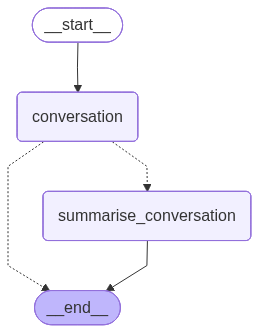

In [7]:
from IPython.display import display, Image
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

pipeline = StateGraph(State)
pipeline.add_node("conversation", call_model)
pipeline.add_node("summarise_conversation", summarise_conversation)
pipeline.add_edge(START, "conversation")
pipeline.add_conditional_edges("conversation", should_continue)
pipeline.add_edge("summarise_conversation",END)

memory = MemorySaver()
graph = pipeline.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))





In [8]:
config = {"configurable": {"thread_id": "1"}}

def chat(human_input):
    input_message = HumanMessage(content=human_input)
    output = graph.invoke({'messages': [input_message]}, config)

    print("\n--- Conversation History (Reverse Order) ---")
    for m in output['messages'][::-1]:
        sender = "User" if m.type == "human" else "AI"
        print(f"{sender}: {m.content}")
    print("-------------------------------------------\n")
    return output



In [9]:
final_state = None

for _ in range(6):
    final_state = chat(human_input=input())

# --- This runs out of the loop, after all 10 steps finish ---
print("===========================================")
print("FINAL CONVERSATION SUMMARY")
print("===========================================")


summary_text = final_state.get('summary', 'No summary was generated during this session.')
print(summary_text)

Responding ...

--- Conversation History (Reverse Order) ---
AI: Namaste Jitu! It's nice to meet you. Is there something I can help you with or would you like to chat?
User: My name is Jitu.
-------------------------------------------

Responding ...
Summarising Requests
Summarization in progress...

--- Conversation History (Reverse Order) ---
AI: I don't have a personal name, but I'm an AI designed to assist and communicate with users in a helpful and informative way. I'm often referred to as a "language model" or a "chatbot." You can think of me as a virtual assistant, here to provide information and answer your questions to the best of my abilities!
User: What is your name?

-------------------------------------------

Responding ...
Summarising Requests
Summarization in progress...

--- Conversation History (Reverse Order) ---
AI: I'm just a computer program, so I don't have feelings or emotions like humans do. However, I'm functioning properly and ready to assist you with any que